In [9]:
import Box2D
import math
from Box2D.b2 import (world, polygonShape, staticBody, dynamicBody)

class BoxEnvironment:
    def __init__(self):
        # Create the world with gravity (0, -10)
        self.world = world(gravity=(0, 0), doSleep=True)
        
        # Create ground (static body)
        self.ground = self.world.CreateStaticBody(
            position=(0, 0),
            shapes=polygonShape(box=(50, 1)),
        )
        
    def create_box(self, x, y, angle,width=1, height=1):
        # Create a dynamic box
        angle_rad = math.radians(angle)
        box = self.world.CreateDynamicBody(
            position=(x, y),
            angle=angle_rad,
            fixtures=[
                Box2D.b2FixtureDef(
                    shape=polygonShape(box=(width/2, height/2)),
                    density=1.0,
                    friction=0.3,
                )
            ]
        )
        return box  
    
    def step(self):
        # Step the physics simulation
        self.world.Step(timeStep=1.0/60, velocityIterations=6, positionIterations=2)


In [51]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

import mujoco


model = mujoco.MjModel.from_xml_path('/home/dhruv/2024/projects/ml4kp_ktamp/resources/models/mujoco_envs_search_push/env_config_1.xml')

# Create environment
env = BoxEnvironment()

# Create a box at position (0, 10)
box1 = env.create_box(1, 1, angle=20, width=1, height=1)
box2 = env.create_box(1, 0, angle=30, width=1, height=1)

# with angle
# plt.figure(figsize=(10, 10))
# rect1 = Rectangle((box1.position[0], box1.position[1]), 1, 1, rotation_point='center', angle=(box1.angle) * 180/np.pi, fill=True, color='red')
# rect2 = Rectangle((box2.position[0], box2.position[1]), 1, 1, rotation_point='center', angle=(box2.angle) * 180/np.pi, fill=True, color='blue')
# plt.xlim(-10, 10)
# plt.ylim(-10, 10)
# plt.gca().add_patch(rect1)
# plt.gca().add_patch(rect2)

env.step()
for contact in box1.contacts:
    if contact.other == box2:
        print("Collision detected")

# check for collision



wall_1 0.05 0.3
wall_2 0.05 0.3
wall_3 1.834044009405148 0.3
wall_4 1.834044009405148 0.3
obstacle_1_movable 0.3586322909184104 0.2
obstacle_2_static 0.37738115751182266 0.2


/tmp/ipykernel_1083990/3477350486.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  body = self.mj_model.body(geom.bodyid)


TypeError: BoxEnvironment.create_box() got multiple values for argument 'angle'

In [67]:
import Box2D
import math
from Box2D.b2 import (world, polygonShape, staticBody, dynamicBody)
from scipy.spatial.transform import Rotation as R
import mujoco

class BoxEnvironment:
    def __init__(self):
        # Load MuJoCo model first to get parameters
        self.mj_model = mujoco.MjModel.from_xml_path('/home/dhruv/2024/projects/ml4kp_ktamp/resources/models/mujoco_envs/env_config_1.xml')
        self.mj_data = mujoco.MjData(self.mj_model)

        mujoco.mj_kinematics(self.mj_model, self.mj_data)
        mujoco.mj_forward(self.mj_model, self.mj_data)

        mujoco.mj_step(self.mj_model, self.mj_data)
        
        # Create Box2D world with gravity matching MuJoCo
        self.world = world(gravity=(0, 0), doSleep=True)
        
        # Create ground (static body)
        self.ground = self.world.CreateStaticBody(
            position=(0, 0),
            shapes=polygonShape(box=(50, 1)),
        )
        
        self.bodies = {}
        # Initialize objects based on MuJoCo model
        self.initialize_from_mujoco()
        
    def initialize_from_mujoco(self):
        # Step MuJoCo once to get initial positions
        mujoco.mj_step(self.mj_model, self.mj_data)
        
        # Create bodies for each geom in MuJoCo model
        for i in range(self.mj_model.ngeom):
            geom = self.mj_model.geom(i)
            body = self.mj_model.body(geom.bodyid)
            # if body.name == "walls":
            #     print(geom)
            
            # Get position and orientation from MuJoCo
            pos = self.mj_data.geom_xpos[i][:2]  # Only take x,y coordinates
            # if "movable" in geom.name :
            #     print(self.mj_model.geom(geom.name).quat)

            quat = R.from_quat(self.mj_model.geom(geom.name).quat).as_quat(scalar_first=False)
            angle = math.atan2(2.0 * (quat[0] * quat[3] + quat[1] * quat[2]),
                             1.0 - 2.0 * (quat[2] * quat[2] + quat[3] * quat[3]))
            
            # Create Box2D body based on MuJoCo geom type
            if geom.type == mujoco.mjtGeom.mjGEOM_BOX:
                self.bodies[geom.name] = self.create_box([pos[0] - geom.size[0], pos[1] - geom.size[1]], angle, geom.size[0]*2, geom.size[1]*2 , 0.1, geom.name)
            elif geom.type == mujoco.mjtGeom.mjGEOM_SPHERE:
                # For spheres, create a small box in Box2D
                radius = geom.size[0]
                self.bodies[geom.name] = self.create_box(pos, angle, radius, radius, 
                              0.1, geom.name)
                
    def create_box(self, pos, angle, width, height, mass, name):
        # Create dynamic body
        body = self.world.CreateDynamicBody(
            position=pos,
            angle=angle,
            fixtures=[
                Box2D.b2FixtureDef(
                    shape=polygonShape(box=(width/2, height/2)),
                    density=mass/(width*height),  # Approximate density from mass
                    friction=0.3,
                )
            ]
        )
        body.userData = name
        return body
        
    def step(self):
        # Step the physics simulation
        self.world.Step(timeStep=1.0/60, velocityIterations=6, positionIterations=2)

env = BoxEnvironment()


/tmp/ipykernel_1083990/2531930772.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  body = self.mj_model.body(geom.bodyid)


In [69]:

name = "obstacle_1_movable"
for contact in env.bodies[name].contacts:
    print(contact)
    # if contact.other == env.bodies["walls"]:
    print("Collision detected")

body = env.bodies[name]
# print(body.position)
# new_x = 2.0
# new_y = 1.0
new_angle = math.radians(45)

# body.position = (new_x, new_y)
body.angle = new_angle
env.step()


b2ContactEdge(contact=b2Contact(childIndexA=0,
                                childIndexB=0,
                                enabled=True,
                                fixtureA=b2Fixture(body=b2Body(active=True,
                                                               angle=0.0,...  ),
              other=b2Body(active=True,
                           angle=0.0,
                           angularDamping=0.0,
                           angularVelocity=0.0,
                           awake=True,
                           bullet=False,
                           contacts=[b2ContactEdge(contact=b2Contact(childIndexA=0,...  ),
              )
Collision detected


wall_1 0.10000000149011612 4.881298065185547
wall_2 0.10000000149011612 4.881298065185547
wall_3 3.668087959289551 0.10000000149011612
wall_4 3.668087959289551 0.10000000149011612
obstacle_1_movable 0.7172645926475525 0.7103285789489746
obstacle_2_static 0.7547622919082642 0.5836617946624756


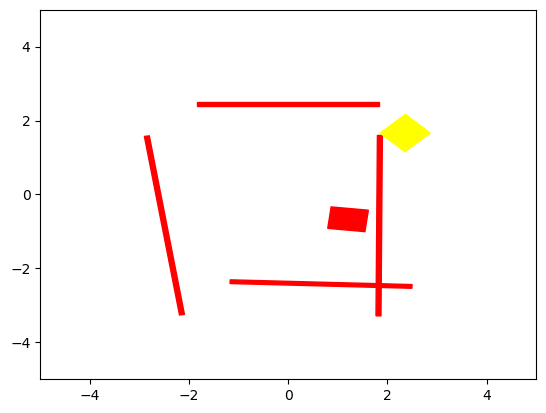

In [70]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111)
# plot all bodies except robot
for i in env.bodies.keys():
    if i == "robot": continue
    fixture = env.bodies[i].fixtures[0]
    shape = fixture.shape
    width = shape.vertices[2][0] * 2
    height = shape.vertices[2][1] * 2
    print(i, width, height)
    # ad
    color = 'red'
    if 'movable' in i:
        color = 'yellow'
    
    rect = Rectangle((env.bodies[i].position[0], env.bodies[i].position[1]), width, height, rotation_point='center', angle=(env.bodies[i].angle) * 180/np.pi, fill=True, color=color)
    ax.add_patch(rect)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.show()


In [31]:
import mujoco

spec = mujoco.MjSpec.from_file("/home/dhruv/2024/projects/ml4kp_ktamp/resources/models/mujoco_envs_search_push/env_config_compile.xml")

body = spec.worldbody.add_body(name="obstacle_1_movable")
body.add_geom(name="obstacle_1_movable", type=mujoco.mjtGeom.mjGEOM_BOX, size=[0.35, 0.35, 0.2], pos=[1.0, 1.0, 0.2], euler=[0, 0, 45])
body.add_joint(type=mujoco.mjtJoint.mjJNT_FREE)

# Function that recursively prints all body names
def print_bodies(parent, level=0):
  body = parent.first_body()
  while body:
    print(''.join(['-' for i in range(level)]) + body.name)
    print_bodies(body, level + 1)
    body = parent.next_body(body)

print_bodies(spec.worldbody)

model = spec.compile()
spec.to_xml()

obstacle_1_movable


'<mujoco model="generated_environment">\n  <compiler angle="radian"/>\n\n  <option timestep="0.01" integrator="RK4" cone="elliptic"/>\n\n  <visual>\n    <map force="1"/>\n    <scale forcewidth="0.005" contactwidth="1" contactheight="0.04"/>\n    <rgba contactforce="0.2 0.98 0.2 0.8"/>\n  </visual>\n\n  <default>\n    <geom density="1"/>\n  </default>\n\n  <asset>\n    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.7" rgb2="0 0 0" width="512" height="3072"/>\n    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3" markrgb="0.8 0.8 0.8" width="300" height="300"/>\n    <texture type="cube" name="body" builtin="flat" mark="cross" rgb1="0.8 0.6 0.4" rgb2="0.8 0.6 0.4" markrgb="1 1 1" width="128" height="768"/>\n    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>\n    <material name="body" texture="body" texuniform="true" rgba="0.8 0.6 0.4 1"/>\n    <material name="robot"

[-0.29039899  1.25400295  0.1995095 ]
[ 1.33207771 -0.16315072  0.1995095 ]
[-0.62166628  0.16491143  0.1995095 ]
[-0.80253461 -0.39619613  0.1995095 ]
[-0.98195815  0.60285964  0.1995095 ]
[-0.8233412   0.10303456  0.1995095 ]
[ 1.46436515 -0.07720353  0.1995095 ]
[ 1.86676347 -0.53017985  0.1995095 ]
[-0.98633824 -0.39719732  0.1995095 ]
[ 1.25565063 -0.94334829  0.1995095 ]


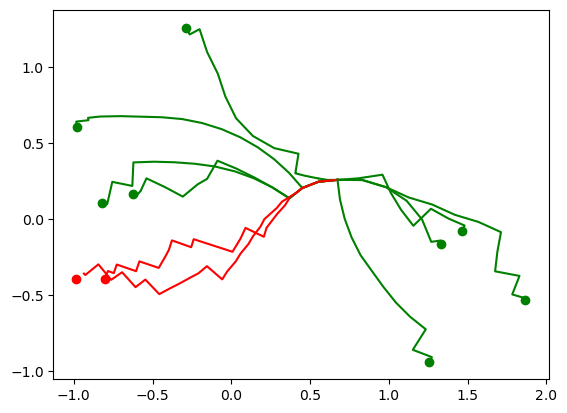

In [4]:
import os
import pickle
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R

with open('/home/dhruv/2024/projects/ml4kp_ktamp/execution_data.pkl', 'rb') as file:
    data = pickle.load(file)
fig = plt.figure()
ax1 = fig.add_subplot(111)
# ax1.set_xlim(-1, 1)
# ax1.set_ylim(-1, 1)
# ax2 = fig.add_subplot(122)
# ax2.set_xlim(-1, 1)
# ax2.set_ylim(-1, 1)

for i in data:
    traj = np.array(i['trajectory'])
    print(i['goal_obstacle_pos'])
    # rot = R.from_quat(traj[:, 3:7], scalar_first=False).as_euler('xyz')

    if not i['execution_success']:
        ax1.scatter(i['goal_obstacle_pos'][0], i['goal_obstacle_pos'][1], color='red')
        ax1.plot(traj[:, 0], traj[:, 1], 'r')
    else:
        ax1.scatter(i['goal_obstacle_pos'][0], i['goal_obstacle_pos'][1], color='green')
        ax1.plot(traj[:, 0], traj[:, 1], 'g')


In [1]:
import os
import pickle
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R
from glob import glob

# with open('/home/dhruv/2024/projects/ml4kp_ktamp/data/execution_data_49.pkl', 'rb') as file:
#     data = pickle.load(file)


data_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/execution_dataset/2"

all_data = []
total_ctr = 0
execution_success_ctr = 0
for i in range(len(glob(f'{data_folder}/execution_data_*.pkl'))):
    try:
        with open(f'{data_folder}/execution_data_{i}.pkl', 'rb') as file:
            data = pickle.load(file)
        all_data.extend(data)
        for j in range(len(data)):
            execution_success_ctr += data[j]['execution_success'] * 1.0
        total_ctr += len(data)
    except Exception as e:
        print(e)
        continue

# data_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/execution_data_10"

# all_data = []
# for i in range(len(glob(f'{data_folder}/execution_data_*.pkl'))):
#     try:
#         with open(f'{data_folder}/execution_data_{i}.pkl', 'rb') as file:
#             data = pickle.load(file)
#         all_data.extend(data)
#     except Exception as e:
#         print(e)
#         continue
# print(len(all_data))


# print(execution_success_ctr / total_ctr)
print(len(all_data))


11600


In [4]:
execution_success_ctr /  total_ctr

0.9646551724137931

In [5]:
time_taken = np.array([all_data[i]['time_taken'] for i in range(len(all_data))])
print(np.sum(time_taken <= 30)/ time_taken.shape[0])

0.48379310344827586


In [14]:
np.array([i['execution_success'] * 1.0 for i in all_data]).sum() / len(all_data)

0.9646551724137931

In [50]:
from tqdm import tqdm
from matplotlib.patches import Rectangle


def get_rect(pos, quat, size, color, alpha=1.0):
    angle = (R.from_quat(quat, scalar_first=True).as_euler('xyz')[2]) * 180/np.pi
    rect = Rectangle((pos[0] - size[0], pos[1] - size[1]), size[0]*2, size[1]*2, rotation_point='center', angle=angle, fill=True, color=color, alpha=alpha)
    return rect
static_patches = []
movable_patches = []
goal_patches = []

data = all_data[np.random.randint(len(all_data))]
patch = {}
for key in data['static_obstacle_states'].keys():
    patch[key] = get_rect(data['static_obstacle_states'][key]['position'][:2], data['static_obstacle_states'][key]['orientation'], data['static_obstacle_sizes'][key], 'red')
static_patches.append(patch.copy())
# for d in data:
for traj in data['trajectory']:
    obstacle_name = data['obstacle_name']
    patch = {}
    for key in traj.keys():
        if obstacle_name == key:
            color = 'blue'
            # goal_patch = get_rect(d['goal_obstacle_pos']['position'][:2], d['goal_obstacle_pos']['orientation'], d['movable_obstacle_sizes'][key], 'green')
        else:
            color = 'yellow'
        patch[key] = get_rect(traj[key]['position'][:2], traj[key]['orientation'], data['movable_obstacle_sizes'][key], color)
    movable_patches.append(patch)
# print(movable_patches)
# print(static_patches)
print(len(movable_patches))

# fig, ax = plt.subplots(1, 1)
# for p in movable_patches:
#     for key in p.keys():
#         ax.add_patch(p[key])
# ax.set_xlim(-2, 2)
# ax.set_ylim(-2, 2)
# ax.axis('off')
# plt.tight_layout()
# plt.show()

46


In [2]:
from PIL import Image
def get_rect(pos, quat, size, color, alpha=1.0):
    angle = (R.from_quat(quat, scalar_first=True).as_euler('xyz')[2]) * 180/np.pi
    rect = Rectangle((pos[0] - size[0], pos[1] - size[1]), size[0]*2, size[1]*2, rotation_point='center', angle=angle, fill=True, color=color)
    return rect

data_images_folder = "/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/NAMO/test1/data_npy"
success_folder = f"{data_images_folder}/success"
failure_folder = f"{data_images_folder}/failure"
os.makedirs(success_folder, exist_ok=True)
os.makedirs(failure_folder, exist_ok=True)
from tqdm import tqdm
from matplotlib.patches import Rectangle
from scipy.spatial.transform import Rotation as R

for i in tqdm(range(2000, 3000)):  
    fig_1, ax_1 = plt.subplots(1, 1, figsize=(5, 5))
    fig_2, ax_2 = plt.subplots(1, 1, figsize=(5, 5))
    fig_3, ax_3 = plt.subplots(1, 1, figsize=(5, 5))
    fig_4, ax_4 = plt.subplots(1, 1, figsize=(5, 5))

    all_rects = []

    for key in all_data[i]['static_obstacle_states']:
        obs_pos = all_data[i]['static_obstacle_states'][key]['position'][:2]
        obs_quat = all_data[i]['static_obstacle_states'][key]['orientation']
        obs_angle = R.from_quat(obs_quat, scalar_first=True).as_euler('xyz')[2]
        obs_size = all_data[i]['static_obstacle_sizes'][key]
        rect = get_rect(obs_pos, obs_quat, obs_size, 'black')
        ax_1.add_patch(rect)
        rect_copy = get_rect(obs_pos, obs_quat, obs_size, 'black')
        all_rects.append(rect_copy)
    obs_rects = []
    goal_rect = []

    for key in all_data[i]['states']:
        if all_data[i]['obstacle_name'] == key:
            obs_pos = all_data[i]['goal_obstacle_pos'][:2]
            obs_quat = all_data[i]['goal_obstacle_quat']
            obs_angle = R.from_quat(obs_quat, scalar_first=True).as_euler('xyz')[2]
            obs_size = all_data[i]['movable_obstacle_sizes'][key]
            rect = get_rect(obs_pos, obs_quat, obs_size, 'black')
            goal_rect.append(rect)
            
        
        obs_pos = all_data[i]['trajectory'][0][key]['position'][:2]
        obs_quat = all_data[i]['trajectory'][0][key]['orientation']
        obs_angle = R.from_quat(obs_quat, scalar_first=True).as_euler('xyz')[2]
        obs_size = all_data[i]['movable_obstacle_sizes'][key]
        color = 'black'
        # if all_data[i]['obstacle_name'] == key:
        #     color = 'blue'
        rect = get_rect(obs_pos, obs_quat, obs_size, color)
        obs_rects.append(rect)
        rect_copy = get_rect(obs_pos, obs_quat, obs_size, color)
        all_rects.append(rect_copy)

    for rect in obs_rects:
        ax_2.add_patch(rect)
       
    
    for rect in goal_rect:
        ax_3.add_patch(rect)
        
    for rect in all_rects:
        ax_4.add_patch(rect)
    # color = 'red'
    # if all_data[i]['execution_success']:
    #     color = 'green'
    # traj = []
    # obs_name = all_data[i]['obstacle_name']
    # for j in range(len(all_data[i]['trajectory'])):
    #     traj.append(all_data[i]['trajectory'][j][obs_name]['position'][:2])
    # traj = np.array(traj)
    # ax.plot(traj[:, 0], traj[:, 1], color=color)
        
    axes = [ax_1, ax_2, ax_3, ax_4]
    for ax in axes:
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.axis('off')
        
    # save fig as black and white
    fig_1.savefig('test_1.png', bbox_inches='tight', pad_inches=0)
    fig_2.savefig('test_2.png', bbox_inches='tight', pad_inches=0)
    fig_3.savefig('test_3.png', bbox_inches='tight', pad_inches=0)  
    fig_4.savefig('test_4.png', bbox_inches='tight', pad_inches=0)
    imgs = ['test_1.png', 'test_2.png', 'test_3.png', 'test_4.png']
    imgs_arrays = []
    for img_path in ['test_1.png', 'test_2.png', 'test_3.png', 'test_4.png']:
        # Read image and ensure it's grayscale
        img = Image.open(img_path).convert('L')
        
        # Convert to numpy array and ensure uint8 format
        img_array = np.array(img, dtype=np.float32)
        img_array[img_array > 0] = 1.0
        imgs_arrays.append(img_array)

    combined_img = np.stack(imgs_arrays, axis=-1)
    if all_data[i]['time_taken'] <= 40:
        np.save(f'{success_folder}/trajectory_{i}.npy', combined_img)
    else:
        np.save(f'{failure_folder}/trajectory_{i}.npy', combined_img)
    plt.close('all')

100%|██████████| 1000/1000 [01:24<00:00, 11.86it/s]


(385, 387, 4)

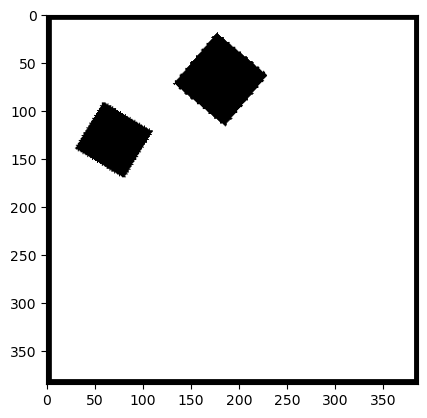

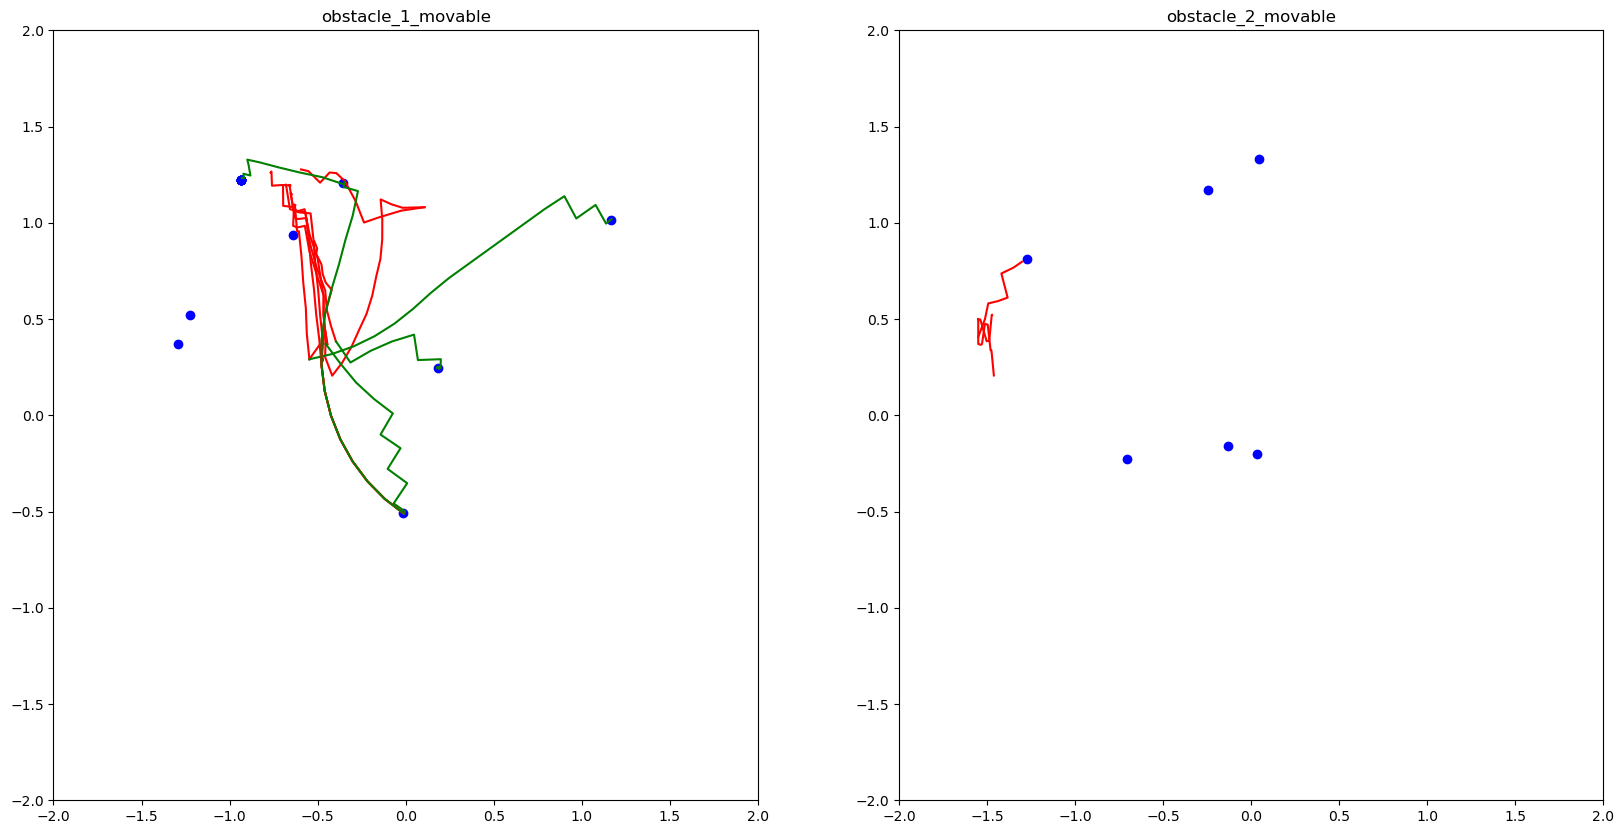

In [76]:


obstacle_to_color = {}
color_idx = 0
obstacle_to_idx = {}
ctr = 0
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'brown', 'pink', 'gray', 'black']
for i in range(len(data)):
    obstacle_name = data[i]['obstacle_name']
    if obstacle_name not in obstacle_to_color:
        obstacle_to_color[obstacle_name] = colors[ctr]
        obstacle_to_idx[obstacle_name] = ctr
        ctr += 1
num = len(obstacle_to_color.keys())
fig, axes = plt.subplots(1, num, figsize=(20, 10))
if num == 1: 
    ax = [axes]
else:
    ax = axes.flatten()

for i in range(len(data)):
    obstacle_name =data[i]['obstacle_name']
    trajectory = data[i]['trajectory']
    goal_obstacle_pos = data[i]['goal_obstacle_pos']
    
    ax[obstacle_to_idx[obstacle_name]].set_title(obstacle_name)
    ax[obstacle_to_idx[obstacle_name]].scatter(goal_obstacle_pos[0], goal_obstacle_pos[1], color='blue')
    color = obstacle_to_color[obstacle_name]
    color = 'red'
    if data[i]['execution_success']:
        color = 'green'
    traj = []
    for j in range(len(trajectory)):
        # print(trajectory[j])
        if type(trajectory[j]) == dict:
            traj.append(trajectory[j][obstacle_name]['position'][:2]) 
    traj = np.array(traj)
    ax[obstacle_to_idx[obstacle_name]].plot(traj[:, 0], traj[:, 1], color=color)

    ax[obstacle_to_idx[obstacle_name]].set_xlim(-2, 2)
    ax[obstacle_to_idx[obstacle_name]].set_ylim(-2, 2)
plt.show()


In [14]:
img = plt.imread(f"{success_folder}/trajectory_1.png")
img.shape

(450, 610, 4)